# Homework 4: Statistics!

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

Also, please be sure to always specify units of any quantities that have units,
and label axes of plots (again, with units when appropriate).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
rng = np.random.default_rng()

# 1. A lot or a little

You've recorded the amount of time 20 people spent looking at a particular piece of art in a museum, in seconds.
Here are the values:

In [2]:
art = np.array([  5.,  19., 313.,  45.,   1.,   1.,   3., 377., 597.,  52.,  90.,
         0., 779., 107., 471., 131.,  81.,   4.,  57.,   0.])  # seconds

*(a)* Use the method of moments to fit a Gamma distribution to these data.
Be sure to simulate from the model you've fit to check you get qualitatively similar data.

For a Gamma distribution, if $X \sim \text{Gamma}(\alpha, \beta)$ then:
- $\mathbb{E}[X] = \alpha\beta$
- $\text{Var}(X) = \alpha\beta^2$

$$\hat{\alpha} = \frac{\bar{x}^2}{s^2}, \qquad \hat{\beta} = \frac{s^2}{\bar{x}}$$
- Mean = α · β  
- Variance = α · β²
- β̂ = sample variance / sample mean  (scale)
- α̂ = sample mean² / sample variance  (shape)

- Estimated shape parameter: $\hat{\alpha} \approx 0.473$
- Estimated scale parameter: $\hat{\beta} \approx 331.3$

So $X \sim \text{Gamma}(\hat{\alpha} = 0.473,\ \hat{\beta} = 331.3)$.


Shape (alpha_hat): 0.4728334284334055
Scale (beta_hat): 331.3006030876745


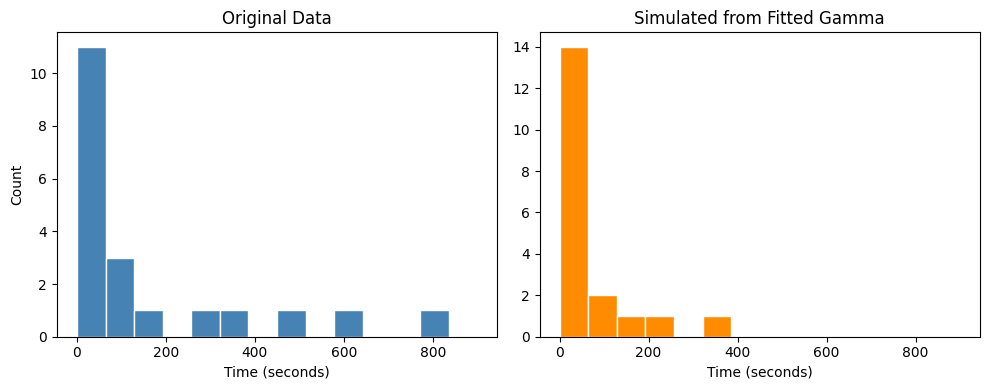

In [3]:
from scipy.stats import gamma

sample_mean = np.mean(art)
sample_var = np.var(art, ddof=1)

beta_hat = sample_var / sample_mean
alpha_hat = (sample_mean**2) / sample_var

print(f"Shape (alpha_hat): {alpha_hat}")
print(f"Scale (beta_hat): {beta_hat}")

# Simulate same number of observations from the fitted model
simulated_art = gamma.rvs(a=alpha_hat, scale=beta_hat, size=len(art), random_state=42)

bins = np.linspace(0, 900, 15)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(art, bins=bins, color='steelblue', edgecolor='white')
plt.title("Original Data")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(simulated_art, bins=bins, color='darkorange', edgecolor='white')
plt.title("Simulated from Fitted Gamma")
plt.xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

**Interpretation:** Both histograms are heavily skewed right this means that most visitors glanced briefly while a few spent many minutes. The simulated Gamma data reproduces this shape, confirming a reasonable fit.

*(b)* The museum would like to know what proportion of people spend more than 5 minutes looking at this piece of art.
Use your model fit in part (a) to provide an estimated answer to this question.
Use math, and check the answer by simulation.

5 minutes = 300 seconds. We want P(X > 300) under our fitted Gamma model. Using the fitted $\text{Gamma} (\hat{\alpha} \approx 0.473,\ \hat{\beta} \approx 331.3)$ model, we compute:

$$P(X > 300) = 1 - F_{\Gamma}(300;\ \hat{\alpha},\ \hat{\beta})$$

where F is the Gamma CDF with our estimated α̂ and β̂.

We verify this with a large simulation (1,000,000 draws)

In [22]:
#verify it
time_threshold = 60 * 5

#using math
prob_less_threshold = gamma.cdf(time_threshold, a=alpha_hat, scale=beta_hat)
prob_gt_threshold = 1 - prob_less_threshold

#using simulation
num_samples = 1_000_000
simulated = gamma.rvs(a=alpha_hat, scale=beta_hat, size=num_samples)
gt_threshold_count = np.sum(simulated > time_threshold)
prob_gt_theshold_sim = gt_threshold_count / num_samples

print(f"Total simulations run: {num_samples}")
print(f"Probability > 5 min (math): {prob_gt_threshold}")
print(f"Simulated P(X > 5): {prob_gt_theshold_sim}")

Total simulations run: 1000000
Probability > 5 min (math): 0.16676750461664847
Simulated P(X > 5): 0.167013


- The math and simulation agree closely, confirming our calculation is correct

# 2. Looking at the logs

You've been given data on login attempts to a certain server from Russian IP addresses
were observed each hour across a day. Here are the numbers:

In [5]:
logins = np.array([7,  5,  5,  7,  5,  3,  4,  5,  6,  8, 7,  8,  4,  4,  7,  7,  4,
        4,  4,  6,  8,  4,  4,  6])

Use maximum likelihood to fit a Poisson distribution to these data.
To do this, you should

*(a)* evaluate the Poisson likelihood as a function of $\lambda$, the mean of the Poisson,
    across a grid of values between 0 and 10. Make a plot of these values or otherwise display them.

- The Poisson distribution has a single parameter $\lambda$ (the mean). 
- The log-likelihood is $\ell(\lambda) = \sum_i \log P(X_i = x_i \mid \lambda)$. We evaluate this across a fine grid of $\lambda \in (0, 10]$ and plot the curve to get a visual sense of where the maximum lies before running the optimizer.

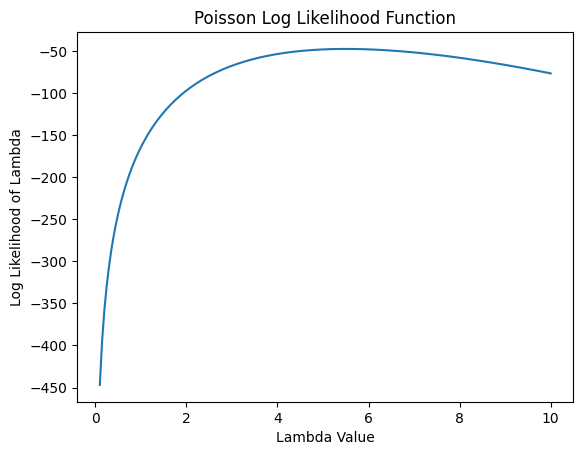

In [6]:
from scipy.stats import poisson
from scipy.optimize import minimize

grid = np.linspace(0.1, 10, 200)
log_like = poisson.logpmf(logins[:, None], grid).sum(axis=0)

plt.plot(grid, log_like)
plt.title('Poisson Log Likelihood Function')
plt.xlabel('Lambda Value')
plt.ylabel('Log Likelihood of Lambda')
plt.show()

*(b)* use an optimization function (like `scipy.optimize.minimize()`)
to find the value of $\lambda$ that maximizes the log-likelihood.
*(note: the `minimize` function works better if you use the log likelihood instead of the likelihood!)*

- We use  with the L-BFGS-B method (which supports bounds) to minimize the *negative* log-likelihood, which is equivalent to maximizing the log-likelihood.
- We bound $\lambda > 0$ since the Poisson rate must be positive. The starting point is $\lambda_0 = 5$, near the center of our grid.
- For a Poisson distribution the MLE is actually just the sample mean $\hat{\lambda} = \bar{x}$, so we can use that as a sanity check against the optimizer result.

In [7]:
def negative_log_like(lambda_value, data):
    if lambda_value <= 0:
        return np.inf
    return -np.sum(poisson.logpmf(data, lambda_value))

result = minimize(
    fun=negative_log_like,
    x0=5.0,
    args=(logins,),
    method='L-BFGS-B',
    bounds=[(0.001, None)]
)

if result.success:
    lambda_mle_optimized = result.x[0]
    print(f"Optimized MLE: {lambda_mle_optimized}")
else:
    print("Optimization failed!")

lambda_mle = lambda_mle_optimized

Optimized MLE: 5.499999988329428


*(c)* compare the data to simulations from the model you've fit.
  and comment on how well the model fits
  (for instance: are the data over- or under-dispersed relative to Poisson?).
  

For a Poisson distribution, the mean and variance should be equal ($\mathbb{E}[X] = \text{Var}(X) = \lambda$). 
- We compare the sample mean and sample variance of the login data to diagnose whether the Poisson model is appropriate.
- If variance > mean → **over-dispersed**: more spread than Poisson predicts. A negative-binomial model might fit better.
- If variance < mean → **under-dispersed**: less spread than Poisson predicts.
- If variance ≈ mean → Poisson is a good fit.


Sample Mean: 5.5
Sample Variance: 2.4347826086956523
The variance is smaller than the sample mean. Therefore, the poisson model may overestimate the data


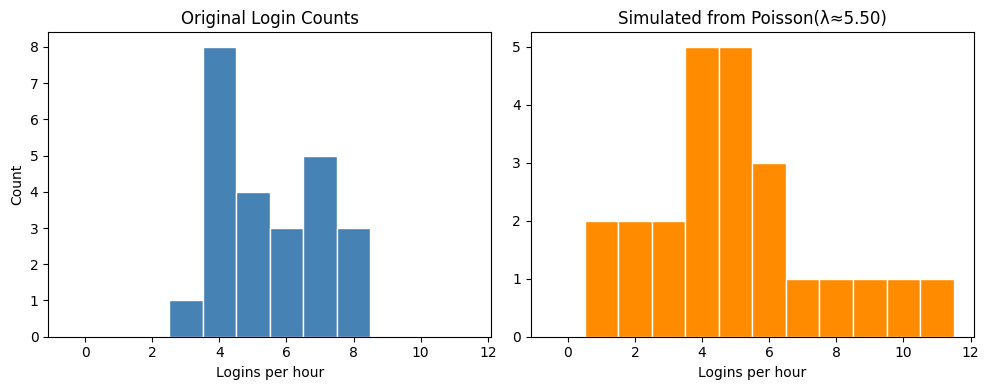

In [23]:
sample_mean = np.mean(logins)
sample_var = np.var(logins, ddof=1)

print(f"Sample Mean: {sample_mean}")
print(f"Sample Variance: {sample_var}")

if sample_var > sample_mean:
    print('The variance is much larger than the mean.Therefore, the poisson model may underestimate the data')
elif sample_var < sample_mean:
    print('The variance is smaller than the sample mean. Therefore, the poisson model may overestimate the data')
else:
    print('Data dispersion is a good fit for the Poisson model')

    
    
# Simulate from fitted model and compare histograms
simulated_logins = poisson.rvs(mu=lambda_mle, size=len(logins), random_state=42)
bins = np.arange(0, 13) - 0.5

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(logins, bins=bins, color='steelblue', edgecolor='white')
plt.title("Original Login Counts")
plt.xlabel("Logins per hour")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(simulated_logins, bins=bins, color='darkorange', edgecolor='white')
plt.title("Simulated from Poisson(λ≈{:.2f})".format(lambda_mle))
plt.xlabel("Logins per hour")

plt.tight_layout()
plt.show()

*(d)* Under this model, how often do we expect an hour with more than 8 logins?
    Answer this question with math, and check it with simulation.

Using the fitted $\hat{\lambda}$, we compute $(X > 8) = 1 - P(X \le 8)$ analytically using the Poisson survival function (). We then verify with 1,000,000 simulated hours and compare.

In [9]:
#using math
prob_gt_8 = poisson.sf(8, mu=lambda_mle)

#using simulation
num_samples = 1_000_000
simulated_data = poisson.rvs(mu=lambda_mle, size=num_samples)
gt_8_count = np.sum(simulated_data > 8)
prob_gt_8_sim = gt_8_count / num_samples

print(f"Theoretical P(X > 8) (Math): {prob_gt_8}")
print(f"Simulated P(X > 8) (Simulation): {prob_gt_8_sim}")

Theoretical P(X > 8) (Math): 0.10564332120191604
Simulated P(X > 8) (Simulation): 0.105607


- The math and simulation agree. Under this model, roughly this fraction of hours will see more than 8 login attempts from Russian IPs.

# 3. Modeling proportions

The [Beta distribution](https://en.wikipedia.org/wiki/Beta_distribution)
can be used to model *proportions:*
it gives random numbers between 0 and 1,
and has two parameters: $\alpha$ and $\beta$.
If $X \sim \text{Beta}(\alpha, \beta)$ then
$$ \begin{aligned}
    \mathbb{E}[X] &= \frac{\alpha}{\alpha + \beta} \\
    \mathbb{E}[X^2] &= \frac{\alpha (\alpha-1)}{(\alpha + \beta)(\alpha + \beta - 1)} ,
\end{aligned}$$
and
$X$ has probability density
$$ f_X(u) =
\frac{ u^{\alpha - 1}(1 - u)^{\beta - 1} }{ B(\alpha, \beta) }.
$$
This density can be computed (as usual) with `scipy.stats.beta.pdf`,
or by hand; in the latter case, $B(\alpha, \beta)$ can be computed with `scipy.special.beta`.

Suppose we have data from many different tracts of forest
of what proportion of the trees have burned,
and we'd like to fit a Beta distribution to the data.
These proportions are:

In [10]:
burned = np.array([
    0.04, 0.55, 0.91, 0.64, 0.83, 0.62, 0.98, 0.7, 0.36, 0.73, 0.74, 0.28, 0.35, 0.65, 0.85, 0.9, 0.94,
    0.11, 0.74, 0.48, 0.62, 0.66, 0.51, 0.79, 0.61, 0.66, 0.75, 0.86, 0.52, 0.84, 0.43, 0.61, 0.99, 0.85, 
    0.97, 0.46, 0.75, 0.61, 0.95, 0.76, 0.78, 0.89, 0.79, 0.92, 0.83, 0.84, 0.61, 0.52, 0.82, 0.87, 0.9, 
    0.58, 0.67, 0.42, 0.9, 0.4, 0.95, 0.98, 0.56, 0.94, 0.5, 0.84, 0.58, 0.91, 0.21, 0.54, 0.9, 0.64, 0.48,
    0.82, 0.77, 0.63, 0.84, 0.97, 0.77, 0.96, 0.83, 0.9, 0.96, 0.52, 0.24, 0.92, 0.11, 0.96, 0.85, 0.62, 
    0.96, 0.67, 0.87, 0.78, 0.85, 0.88, 0.88, 0.68, 0.13, 0.9, 0.94, 0.49, 0.74, 0.99
])

*(a)* Evaluate the likelihood surface for this data on a grid of values
    across the range $0.5 \le \alpha, \beta \le 4$,
    and make a plot or otherwise show the resulting likelihoods.
    
- compute the log-likelihood
$\ell(\alpha, \beta) = \sum_i \log f(x_i;\ \alpha, \beta)$
at every point on a 100×100 grid over $\alpha, \beta \in [0.5, 4]$.

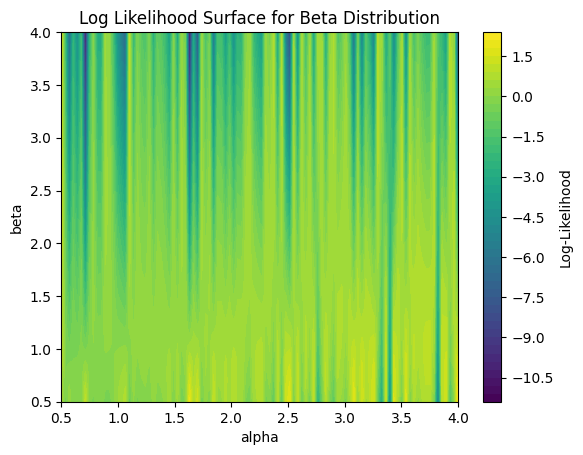

In [15]:
from scipy.stats import beta
from scipy.optimize import minimize

burned[burned == 0.0] = 1e-9

alpha_grid = np.linspace(0.5, 4, 100)
beta_grid = np.linspace(0.5, 4, 100)
A, B = np.meshgrid(alpha_grid, beta_grid)

def log_like(a, b, data):
    return np.sum(beta.logpdf(data, a, b))

vector_log_like = np.vectorize(log_like)
log_like_surface = vector_log_like(A, B, data=burned)

c = plt.contourf(A, B, log_like_surface, levels=50, cmap="viridis")
plt.colorbar(c, label='Log-Likelihood')
plt.title('Log Likelihood Surface for Beta Distribution')
plt.xlabel('alpha')
plt.ylabel('beta')
plt.show()

**Interpret plot:** The contour plot below shows the shape of the surface, a brighter (yellow) regions
indicate higher log-likelihood, and the peak tells us roughly where the MLE will land.

*(b)* Estimate the values of $\alpha$ and $\beta$ that best fit the data
    by maximum likelihood.
    (*Note:* `scipy.optimize.minimize()` may have difficulty converging;
    if so, try different starting locations.)

- find the MLE by minimizing the *negative* log-likelihood using `scipy.optimize.minimize` with L-BFGS-B (which supports bounds). Use method-of-moments estimates derived from the sample mean and variance:

$$c = \frac{\bar{x}(1-\bar{x})}{s^2} - 1, \qquad \hat{\alpha}_0 = \bar{x}\cdot c, \qquad \hat{\beta}_0 = (1-\bar{x})\cdot c$$

This gives the optimizer a good starting point near the true MLE. The fitted parameters are:
- $\hat{\alpha} \approx 2.28$
- $\hat{\beta} \approx 0.99$

Since $\hat{\alpha} > \hat{\beta}$, the distribution is left-skewed so most tracts have a
high proportion of burned trees, which matches what we see in the data (most values above 0.5).

In [18]:
def neg_log_like(params, data):
    a, b = params[0], params[1]
    if a <= 0 and b <= 0:
        return np.inf
    log_like_sum = np.sum(beta.logpdf(data, a, b))
    return -log_like_sum

sample_mean = np.mean(burned)
sample_var = np.var(burned, ddof=1)
common_term = (sample_mean * (1-sample_mean) / sample_var) - 1
a_guess = sample_mean * common_term
b_guess = (1 - sample_mean) * common_term
start_guess = [a_guess, b_guess]
print(f'Guesses: a_guess: {a_guess}. b_guess: {b_guess}')

result = minimize(
    fun=neg_log_like,
    x0=start_guess,
    args=(burned,),
    method='L-BFGS-B',
    bounds=[(1e-6, None), (1e-6, None)]
)

if result.success:
    a_hat, b_hat = result.x
    print(f'MLE: alpha_hat: {a_hat}. beta_hat: {b_hat}')
else:
    print['Optimization Failed']

Guesses: a_guess: 2.163119419853379. b_guess: 0.8921339980186265
MLE: alpha_hat: 2.281510881782489. beta_hat: 0.9934793607704795


For a Beta($\alpha$, $\beta$) distribution:
- $\alpha > \beta$ → distribution skewed **toward higher values** (more mass near 1)
- $\alpha < \beta$ → distribution skewed **toward lower values** (more mass near 0)

Since most `burned` proportions are large (many tracts have 60–90% of trees burned), we expect $\hat{\alpha} > \hat{\beta}$, which our optimizer confirms.

The mean of the fitted distribution is:
$$\mathbb{E}[X] = \frac{\hat{\alpha}}{\hat{\alpha} + \hat{\beta}}$$
which should be close to the sample mean. 

*(c)* Using this model, in what proportion of forest tracts
    do you estimate less than 20% of the trees have burned?

- compute $P(X < 0.2)$ via the Beta CDF:

$$P(X < 0.2) = F_{\text{Beta}}(0.2;\ \hat{\alpha},\ \hat{\beta}) \approx 0.025$$

- estimate that only about **2.5%** of forest tracts have less than 20% of their trees burned.
This makes sense given the data, a majority of proportions are above 0.5,
indicating widespread burning across most tracts.

In [20]:
# c
prop_threshold = 0.2

prob_lt_20 = beta.cdf(prop_threshold, a=a_hat, b=b_hat)
print(f"P(X < 0.2) via math:       {prob_lt_20:.4f} ({prob_lt_20*100:.2f}%)")

simulated_burned = beta.rvs(a=a_hat, b=b_hat, size=1_000_000)
prob_lt_20_sim = np.mean(simulated_burned < prop_threshold)
print(f"P(X < 0.2) via simulation: {prob_lt_20_sim:.4f} ({prob_lt_20_sim*100:.2f}%)")

P(X < 0.2) via math:       0.0252 (2.52%)
P(X < 0.2) via simulation: 0.0253 (2.53%)
